In [5]:
#Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import pandas as pd

#Load dataset and set the first column as the index
df = pd.read_csv('https://github.com/Explore-AI/Public-Data/blob/master/exports%20ZAR-USD-data.csv?raw=true', index_col=0)

#Rename columns to 'Y' for the dependant variable and 'X' for the Independent variable
#Rename the columns of the DataFrame to 'Y' and 'X'
df.columns = ['Y', 'X']


In [6]:
#extract values of X and Y as numpy arrays for mathematical operations
X = df.X.values
Y = df.Y.values

#Calculate mean of X and Y
x_bar = np.mean(X)
y_bar = np.mean(Y)

#Calculate the slope (m) of the regression line using the least squares method
m = sum((X - x_bar) * (Y - y_bar)) / sum((X-x_bar) ** 2)

#Calculate the intercept (c) of the regression line
c = y_bar - m * x_bar

#Output the claculated slope and interest
print("Slope = ", m)
print("Intercept = ", c)

Slope =  0.000113507257658843
Intercept =  1.8448114670426463


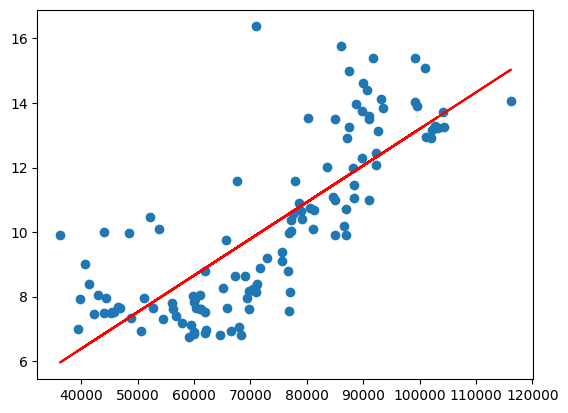

In [7]:
#use the function we created earlier to generate y_values for a given list of x-values, using the calculated slope and intercept
def gen_y(x_list, m, c):
    y_gen = []
    for x_i in x_list:
        y_i = m*x_i + c
        y_gen.append(y_i)

    return(y_gen)

#Generate y_values for the given x-values in the dataseet based on the calculated slope and intercept
y_gen = m * df.X + c

#Plot the original datapoints as a scatter plot
plt.scatter(df.X, df.Y)

#Plot the regression line using the generated y-values
plt.plot(df.X, y_gen, color = 'red')

plt.show()

In [8]:
#Calculate the residuals by subtracting the observed Y values from the generated Y values 
errors2 = np.array(y_gen - df.Y)
#Print the residuals, rounded to 2 decimal places
print(np.round(errors2, 2))

[-0.7  -0.49 -0.32  0.43  0.61  0.75  1.17  1.04  0.72 -0.44 -2.14 -2.62
 -3.94 -3.16 -2.69 -2.54 -1.83 -1.32 -1.06 -1.57 -0.51 -0.63 -0.47 -0.49
 -0.82 -0.55  0.87  0.04  0.19  1.14  1.36  0.74  1.47  1.74  1.93  1.82
  0.67  1.25  2.47  1.82  2.01  2.8   2.37  2.5   2.99  1.75  2.46  1.58
  0.62  1.66  2.15  0.82  1.75  1.53  1.59  1.61  0.98  1.06  1.77  0.83
  0.09  1.1   0.93  1.32  1.06  0.58  1.82  0.96  0.59  1.57  1.47  0.23
 -0.12  0.51  0.24  0.1   0.41  0.4   1.01  0.15  1.2   0.8   0.36  0.42
 -2.04 -0.9   0.25 -0.68 -0.11 -0.26 -0.13 -1.19 -1.44 -2.02 -1.69 -3.21
 -6.47 -4.16 -3.14 -2.56 -2.27 -1.77 -2.27 -1.73 -0.91 -2.05 -0.78 -1.38
 -2.59 -1.49  0.39 -1.33  0.21  0.51 -0.76  0.33  0.28 -0.04  0.97  0.44]


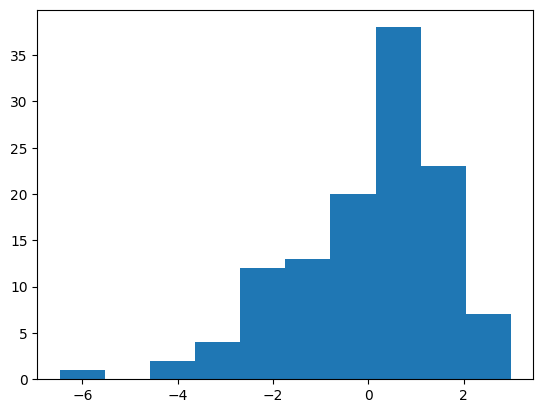

In [9]:
plt.hist(errors2)
plt.show()

In [10]:
#Caluculate the residual sum of squares (RSS) by squaring the residuals and summing them up
print("Residual sum of squares:", (errors2 * 2).sum())

Residual sum of squares: -2.291500322826323e-13


In [11]:
#round off the sum of residuals to 11 decimals places to check for numerical stability or precision issues
np.round(errors2.sum(), 11)

np.float64(-0.0)

Linear regression in sci-kit learn

In [4]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━ 6.6/8.9 MB ? eta -:--:--2:54:22
Resuming download scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB/8.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━ 7.1/8.9 MB 47.8 kB/s eta 0:00:39
Resuming download scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.1 MB/8.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 83.4 kB/s  0:00:21 116.3 kB/s eta 0:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/35.2 MB ? eta -:--:--0m
   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━ 16.0/35.2 MB 196.5 kB/s eta 0:01:38:33
Resuming download scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.0 MB/35.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━ 19.9/35.2 MB ? eta -:--:--m:01
Resuming download scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (19.9 MB/35.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━ 20.4/35.2 MB ? eta -:--:--0:06:1

In [12]:
#Import the Linear Regression class from scikit-learn's linear_model module
from sklearn.linear_model import LinearRegression

Linear regression in sci-kit learn

In [15]:
LinearRegression?

Init signature:
LinearRegression(
    *,
    fit_intercept=True,
    copy_X=True,
    tol=1e-06,
    n_jobs=None,
    positive=False,
)
Docstring:     
Ordinary least squares Linear Regression.

LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
to minimize the residual sum of squares between the observed targets in
the dataset, and the targets predicted by the linear approximation.

Parameters
----------
fit_intercept : bool, default=True
    Whether to calculate the intercept for this model. If set
    to False, no intercept will be used in calculations
    (i.e. data is expected to be centered).

copy_X : bool, default=True
    If True, X will be copied; else, it may be overwritten.

tol : float, default=1e-6
    The precision of the solution (`coef_`) is determined by `tol` which
    specifies a different convergence criterion for the `lsqr` solver.
    `tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` when
    fitting on sparse training da

In [13]:
#Initialize The linear regression model
lm = LinearRegression()

FITTING THE LINEAR MODEL

In [16]:
lm.fit?


Signature: lm.fit(X, y, sample_weight=None)
Docstring:
Fit linear model.

Parameters
----------
X : {array-like, sparse matrix} of shape (n_samples, n_features)
    Training data.

y : array-like of shape (n_samples,) or (n_samples, n_targets)
    Target values. Will be cast to X's dtype if necessary.

sample_weight : array-like of shape (n_samples,), default=None
    Individual weights for each sample.

    .. versionadded:: 0.17
       parameter *sample_weight* support to LinearRegression.

Returns
-------
self : object
    Fitted Estimator.
File:      ~/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_base.py
Type:      method

In [17]:
#Reshape the X array to a 2D array as required by scikit-learn, converting from pandas series to numpy array if necessary
X = df.X.values[:, np.newaxis]

In [18]:
#Fit the linear model to the data
lm.fit(X, df.Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
#Extract the slope (coeficient) and intercept from the fitted model
m = lm.coef_[0]
c = lm.intercept_

In [20]:
#Print the slope and intercept
print("Slope:\t\t", m)
print("Intercept:\t", c)

Slope:		 0.00011350725765884299
Intercept:	 1.844811467042648


Getting model predictions

In [21]:
#Use the fitted model to generate Y values from the X values
gen_y = lm.predict(X)

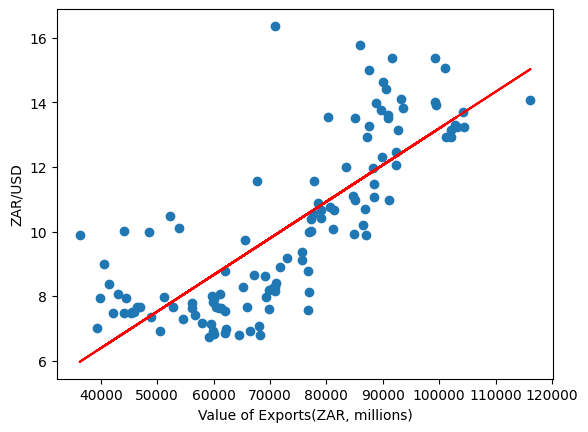

In [22]:
#plot the results
#Plot the orginal data
plt.scatter(X, df.Y)
#Plot the line connecting the generated y-values
plt.plot(X, gen_y, color='red')

#Label the axes
plt.ylabel("ZAR/USD")
plt.xlabel("Value of Exports(ZAR, millions)")
plt.show()

Accessing the model accuracy

In [23]:
#Calculate and print the residual sum of squares (RSS) or the fitted model
print("Residual sum of squares:", ((gen_y - df.Y) ** 2). sum())

Residual sum of squares: 321.4571665525765


In [25]:
#Import metrics from scikit-learn
from sklearn import metrics

In [26]:
#Calculate and print the mean squared error(MSE) between the observed and predicted Y values
print('MSE:', metrics.mean_squared_error(df.Y, gen_y))

MSE: 2.6788097212714708


In [27]:
#Calculate and print the RSS by multiplying the MSE by the number of observations
print("Residual sum of squares:", metrics.mean_squared_error(df.Y, gen_y)*len(X))

Residual sum of squares: 321.4571665525765


In [28]:
#Caclculate and print the R-squared value, a measure of how well the observed values are replicated by the model
print('R-squared:', metrics.r2_score(df.Y, gen_y))

R-squared: 0.6158417476896207
